El conjunto con el que entrenamos (ajustamos, 'fit') el modelo es el conjunto 'train' (entrenamiento). (La mayor parte de los datos, 60%).

Con el conjunto de train entrenamos 3 modelos: un decision tree, un random forest y un gradient boosting.


El conjunto con el que ajustamos los hiperparámetros del modelo (condiciones iniciales, parámetros del modelo) es el conjunto 'validation' (validación).

Sobre el conjunto de validación, evaluamos los modelos y nos quedamos con el modelo que tenga mejor precisión (ajustada/equilibrada).


El conjunto con el que comprobamos el aptitud del modelo es el conjunto 'test' o de prueba.

En el sentido estadístico (el más cercano al caso real), el resultado (precisión/la métrica que sea) más justo/real es el que obtenemos sobre el conjunto de test - porque nunca hemos evaluado el modelo sobre estos datos.



K-Fold Cross Validation

80% y 20%
Separamos los datos en conjuntos de train y test - pero hacemos esto K veces con una separación aleatoria distinta.

K divisiones distintas del conjunto original, cada una con su par (train, test).

Para cada división, aplicamos unos hiperparámetros distintos (alternativamente, si tenemos múltiples modelos en vez de hiperparámetros, aplicamos una división distinta para cada modelo). Al final hacemos una media del resultado en cada división y estimamos que la media (precisión) es el valor "real/final".

Basado en https://github.com/SaturdaysAI-Murcia/machine-learning

# <center> [Adult salaries](https://archive.ics.uci.edu/ml/datasets/adult): Gradient boosting
### <center>Predict whether income exceeds $50K/yr based on census data.

Link: https://www.kaggle.com/mattmet/income-prediction-xgboost-accuracy-86-02

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.ensemble      import ExtraTreesClassifier
from sklearn.ensemble      import GradientBoostingClassifier
from xgboost               import XGBClassifier, plot_tree

from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics         import accuracy_score, balanced_accuracy_score

# Leer CSV

In [ ]:
##### DOWNLOAD DATASET. ONLY IN COLAB !!!
!wget -P ./data/ https://raw.githubusercontent.com/SaturdaysAI-Murcia/machine-learning/master/data/adult.csv

--2024-03-04 12:40:44--  https://raw.githubusercontent.com/SaturdaysAI-Murcia/machine-learning/master/data/adult.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3818789 (3.6M) [text/plain]
Saving to: ‘./data/adult.csv’

adult.csv           100%[===================>]   3.64M  --.-KB/s    in 0.07s   

2024-03-04 12:40:44 (52.0 MB/s) - ‘./data/adult.csv’ saved [3818789/3818789]



In [ ]:
df = pd.read_csv("./data/adult.csv")

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,49,Private,101320,Assoc-acdm,12.0,Married-civ-spouse,NaN,Wife,White,Female,0,1902,40,United-States,>=50k
1,44,Private,236746,Masters,14.0,Divorced,Exec-managerial,Not-in-family,White,Male,10520,0,45,United-States,>=50k
2,38,Private,96185,HS-grad,NaN,Divorced,NaN,Unmarried,Black,Female,0,0,32,United-States,<50k
3,38,Self-emp-inc,112847,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,40,United-States,>=50k
4,42,Self-emp-not-inc,82297,7th-8th,NaN,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,50,United-States,<50k


# Qué queremos predecir? -> `df.salary`

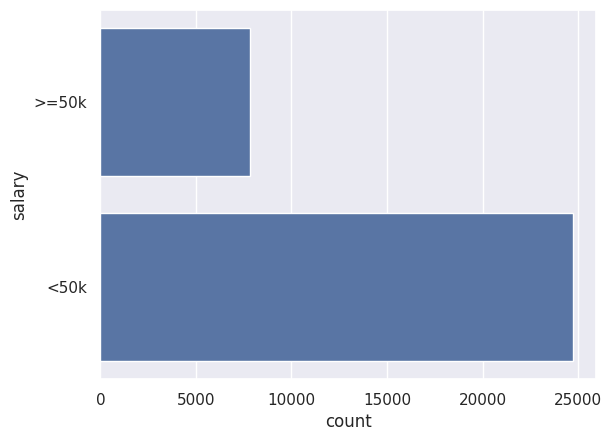

In [ ]:
sns.countplot(df.salary);

# Variables

In [ ]:
cat  = df.select_dtypes(include=[object]).columns
num  = df.select_dtypes(exclude=[object, 'datetime64','timedelta64']).columns
time = df.select_dtypes(include=['datetime64']).columns

print("\nNumerical features:\n", num.values)
print("\nCategorical features:\n", cat.values)
print("\nDate/time features:\n", time.values)


Numerical features:
 ['age' 'fnlwgt' 'education-num' 'capital-gain' 'capital-loss'
 'hours-per-week']

Categorical features:
 ['workclass' 'education' 'marital-status' 'occupation' 'relationship'
 'race' 'sex' 'native-country' 'salary']

Date/time features:
 []


# Missings

In [ ]:
df = df.dropna(axis='rows')

# Categorical

In [ ]:
df[cat] = df[cat].apply(LabelEncoder().fit_transform)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
1,44,4,236746,12,14.0,0,4,1,4,1,10520,0,45,39,1
3,38,5,112847,14,15.0,2,10,0,1,1,0,0,40,39,1
5,20,4,63210,11,9.0,4,6,3,4,1,0,0,15,39,0
8,46,4,328216,11,9.0,2,3,0,4,1,0,0,40,39,1
21,26,4,746432,11,9.0,4,6,3,2,1,0,0,48,39,0


# Models

In [ ]:
x = df[['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'
       ]]
y = df["salary"]

In [ ]:
models = [
    ('Logistic Regression', LogisticRegression(n_jobs=-1)),
    ('Decision Tree',       DecisionTreeClassifier()),
    ('Extra Trees',         ExtraTreesClassifier(n_jobs=-1)),
    ('Random Forest',       RandomForestClassifier(n_jobs=-1)),
    ('Gradient Boosting',   GradientBoostingClassifier()),
    ('XGBoost',             XGBClassifier(n_estimators=250))
]

outcome = []
Modelnames = []

for name, model in models:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    cv_r = cross_val_score(model, x, y, cv=skf, scoring='accuracy')
    outcome.append(cv_r)
    Modelnames.append(name)
    print("%s: %.2f%% (%.2f%%)" % (name, cv_r.mean()*100, cv_r.std()*100))

Logistic Regression: 78.99% (0.63%)
Decision Tree: 81.41% (0.34%)
Extra Trees: 84.59% (0.36%)
Random Forest: 85.73% (0.20%)
Gradient Boosting: 86.56% (0.35%)
XGBoost: 86.40% (0.31%)


In [ ]:
results ={'Names': Modelnames,'Results': outcome}
plt.figure(figsize=(16,6))
results["Results"]
#sns.boxplot(x='Names',y='Results',data=results)

[array([0.78547855, 0.78013516, 0.79377554, 0.79770512, 0.79236089]),
 array([0.8175389 , 0.8084237 , 0.8176674 , 0.81263754, 0.81436655]),
 array([0.84158416, 0.84189848, 0.84706067, 0.84847532, 0.8505187 ]),
 array([0.8550998 , 0.85541411, 0.85680604, 0.85947815, 0.8599497 ]),
 array([0.8607575 , 0.86264341, 0.86576548, 0.86953788, 0.8693807 ]),
 array([0.8588716 , 0.86295772, 0.86387928, 0.86812323, 0.86623703])]

<Figure size 1600x600 with 0 Axes>